# Steuerung — KI-gestützte Dokumentenaufbereitung

**Referenz-Implementierung · Niveau DQR 5/6**

Dieses Notebook ist der **einzige Einstiegspunkt** der Pipeline. Die Module
`schema.py`, `layout.py`, `erkennung.py`, `stapel.py`, `kanonisch.py` und
`sichtung.py` liegen flach daneben und werden von hier importiert, nie
direkt ausgeführt.

## Warum ein Notebook und keine Skripte

Relative Pfade wie `befunde/Buch` werden gegen das **Arbeitsverzeichnis**
aufgelöst, und wer das setzt, hängt am Werkzeug:

| Start über | Arbeitsverzeichnis |
|---|---|
| Jupyter-Kernel | Ordner der Notebook-Datei |
| VS Code, Python-Datei | Workspace-Ordner (oft eine Ebene höher) |

Der Kernel verhält sich ohne jede Einstellung richtig. Deshalb steuert das
Notebook, und die Module bleiben frei von Pfadlogik.

**Wer eine `.py`-Datei doch direkt startet, bekommt das alte Verhalten
zurück.** Abschnitt 0 macht das sichtbar, statt es stillschweigend
zurechtzurücken.

## Ablauf

| Abschnitt | Inhalt | Modell |
|---|---|---|
| 0 | Umgebung prüfen | – |
| 1 | Stufe 1+2: Layout und Erkennung über ein Buch | ONNX + VLM |
| 2 | Sichtung: was steht in den Befunden? | – |
| 3 | Nachlauf für abgeschnittene Blöcke | VLM |
| 4 | Stufe 4a: kanonisches Dokument und Markdown | – |
| 5 | Kontrolle | – |

---
## 0. Umgebung prüfen

Erst nachsehen, dann rechnen. Diese Zelle stellt nichts richtig, sie meldet
nur — ein falsches Arbeitsverzeichnis soll auffallen und nicht kaschiert
werden.

In [ ]:
from pathlib import Path
import sys

# --- Anzupassen
PDF  = Path("data/raw") / "Buch.pdf"
ONNX = Path("models") / "pp_doclayoutv3.onnx"
BEFUNDE = Path("data/interim/befunde")
AUSSCHNITTE = Path("data/interim/ausschnitte")
LMS  = "http://localhost:1234/v1"

BEFUNDE = Path("befunde")
AUSSCHNITTE = Path("ausschnitte")

print("Arbeitsverzeichnis:", Path.cwd())
print("Python            :", sys.version.split()[0], "\n")

for beschriftung, pfad in [("PDF", PDF), ("ONNX-Modell", ONNX),
                           ("Befunde", BEFUNDE / BUCH),
                           ("Ausschnitte", AUSSCHNITTE / BUCH)]:
    zustand = "vorhanden" if pfad.exists() else "fehlt"
    zusatz = ""
    if pfad.is_dir():
        zusatz = f"  ({len(list(pfad.glob('*'))) } Einträge)"
    print(f"  {beschriftung:14s} {zustand:10s} {pfad}{zusatz}")

# Liegt eine Ablage versehentlich eine Ebene höher? Häufigster Fall, wenn
# eine .py-Datei direkt gestartet wurde.
for name in ("befunde", "ausschnitte", "dokumente", "md"):
    fremd = Path("..") / name
    if fremd.exists() and not (Path.cwd() / name).exists():
        print(f"  ! {name!r} liegt eine Ebene höher: {fremd.resolve()}")

Arbeitsverzeichnis: /Users/thomasjorg/Documents/05_VSCode/DQR6_Material/M7b_DocumentExtraction
Python            : 3.12.10 

  PDF            vorhanden  data/raw/Buch.pdf
  ONNX-Modell    vorhanden  models/pp_doclayoutv3.onnx
  Befunde        fehlt      befunde/Buch
  Ausschnitte    fehlt      ausschnitte/Buch


In [2]:
# Module laden. autoreload, damit Änderungen an den .py-Dateien sofort
# wirken, ohne den Kernel neu zu starten.
%load_ext autoreload
%autoreload 2

import schema, layout, erkennung, stapel, kanonisch, sichtung
from schema import Stufe, Strom, befund_laden, befund_pfad

print("Schema-Version:", schema.SCHEMA_VERSION)
print("Klassenabbildung:", schema.selbsttest_docling())

Schema-Version: 1.0
Klassenabbildung: {'klassen': 25, 'verlustfrei': 12, 'verlustbehaftet': 13}


In [7]:
# Ist in LM Studio das richtige Modell geladen? Ein winziges Bild klärt in
# einer Sekunde, was ein Buchlauf sonst auf jeder Seite wiederholt.
from erkennung import Erkenner

ERKENNER = Erkenner(url=LMS)
print(ERKENNER.pruefe() if hasattr(ERKENNER, "pruefe")
      else f"Modell: {ERKENNER.modell_id}")

Modell: mlx-community/paddleocr-vl-1.5


---
## 1. Stufe 1 und 2 über ein ganzes Buch

Der Lauf ist **stufenweise**: erst alle Seiten durch die Layout-Erkennung,
dann alle durch das VLM. Detektor und Sprachmodell sind damit nie
gleichzeitig geladen, die ONNX-Sitzung wird einmal geöffnet.

Fertige Seiten werden übersprungen (A2), gescheiterte übersprungen und
vermerkt (A3), Zeit und Modellversion je Seite festgehalten (A4).

**Erwartete Dauer:** Stufe 1 rund 0,4 s je Seite, Stufe 2 rund 11 s je
Seite. Für 222 Seiten also anderthalb Minuten plus vierzig.

In [8]:
# Erst nur das Layout - kostet Sekunden und braucht kein LM Studio.
lauf = stapel.verarbeite_buch(PDF, buch=BUCH, bis=Stufe.LAYOUT,
                              onnx=ONNX, wurzel=BEFUNDE,
                              ausschnitt_wurzel=AUSSCHNITTE)

Buch: 222 Seiten aus Buch.pdf
--- Stufe 1


/Users/thomasjorg/Documents/05_VSCode/DQR6_Material/M7b_DocumentExtraction/layout.py:68: RuntimeWarning: overflow encountered in exp
  return (1.0 / (1.0 + np.exp(-x.astype(np.float64)))).astype(np.float32)


  S   0    5 Blöcke,  0.57s
  S   1   21 Blöcke,  0.45s
  S   2    7 Blöcke,  0.44s
  S   3    4 Blöcke,  0.39s
  S   4    5 Blöcke,  0.40s
  S   5    2 Blöcke,  0.38s
  S   6    3 Blöcke,  0.43s
  S   7   15 Blöcke,  0.43s
  S   8   50 Blöcke,  0.40s
  S   9    5 Blöcke,  0.43s
  S  10    9 Blöcke,  0.39s
  S  11   14 Blöcke,  0.39s
  S  12    9 Blöcke,  0.39s
  S  13   14 Blöcke,  0.39s
  S  14   14 Blöcke,  0.39s
  S  15   11 Blöcke,  0.39s
  S  16   15 Blöcke,  0.43s
  S  17   17 Blöcke,  0.39s
  S  18   13 Blöcke,  0.37s
  S  19    9 Blöcke,  0.37s
  S  20   12 Blöcke,  0.42s
  S  21   14 Blöcke,  0.38s
  S  22   36 Blöcke,  0.41s
  S  23   24 Blöcke,  0.39s
  S  24   20 Blöcke,  0.39s
  S  25   20 Blöcke,  0.39s
  S  26   23 Blöcke,  0.37s
  S  27   13 Blöcke,  0.34s
  S  28    9 Blöcke,  0.44s
  S  29   12 Blöcke,  0.42s
  S  30   14 Blöcke,  0.40s
  S  31   11 Blöcke,  0.41s
  S  32   14 Blöcke,  0.39s
  S  33   13 Blöcke,  0.39s
  S  34   22 Blöcke,  0.40s
  S  35   31 Blöcke,

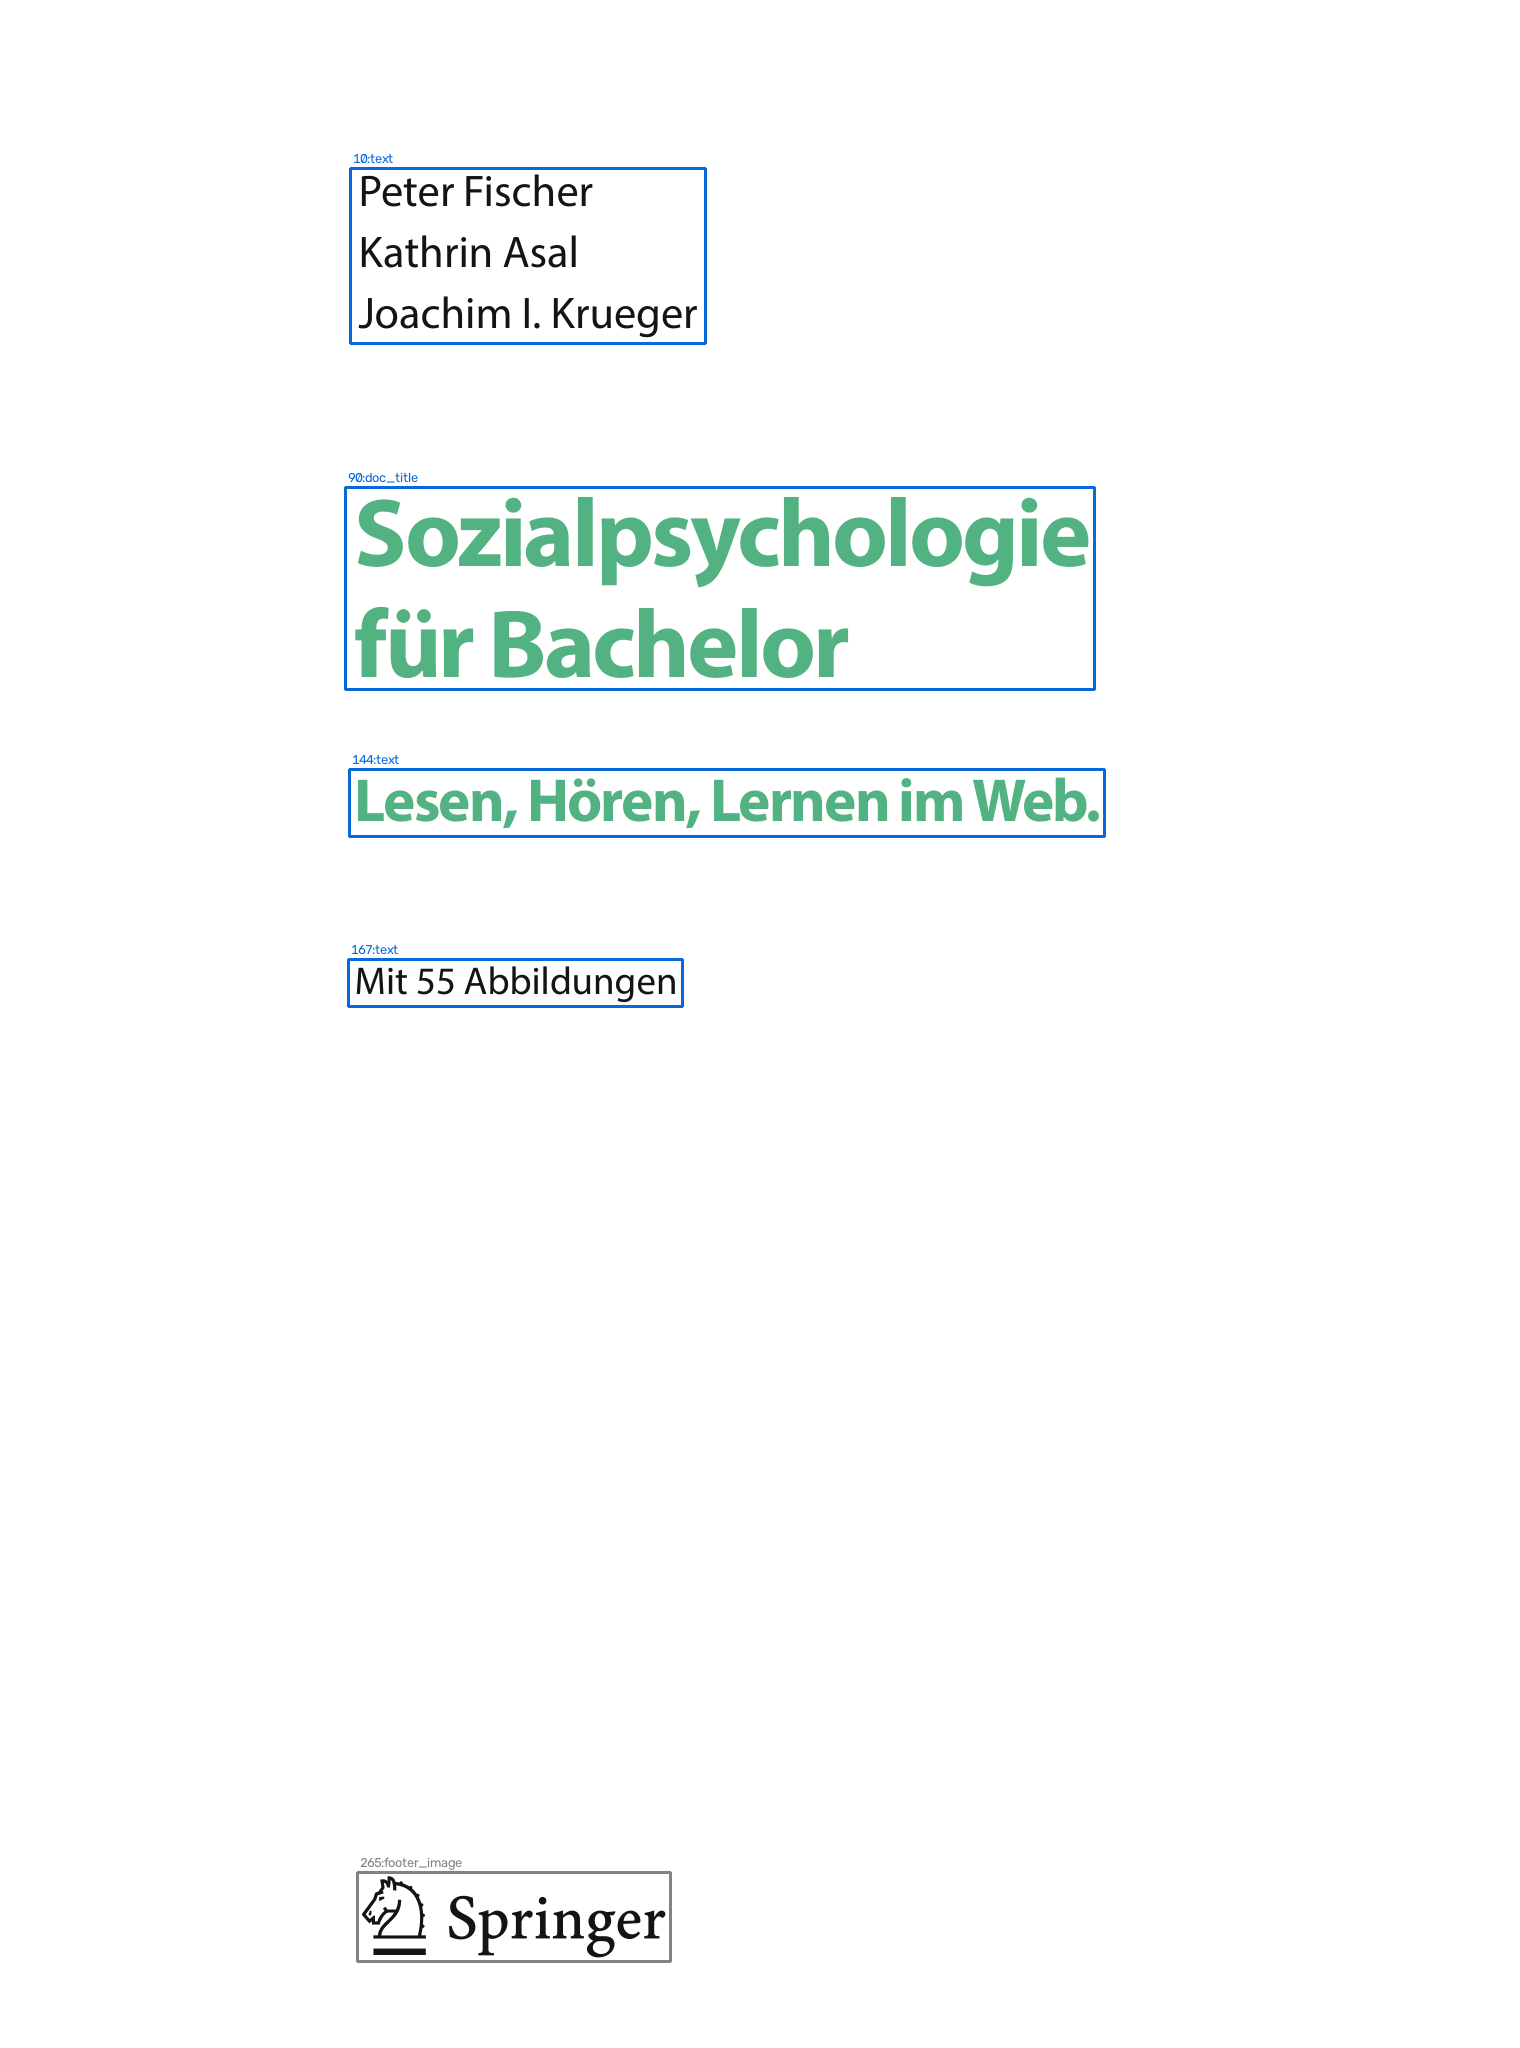

In [9]:
# Kontrolle vor dem teuren Teil: eine Seite als Overlay ansehen.
from IPython.display import Image, display
import cv2

SEITE = 0
befund = befund_laden(befund_pfad(BEFUNDE, BUCH, SEITE))
bild, _ = layout.seite_rendern(PDF, seite=SEITE)

Path("data/interim/kontrolle").mkdir(exist_ok=True)
ziel = Path("data/interim/kontrolle") / f"{BUCH}_{SEITE:04d}.png"

farben = {Strom.HAUPT: (9, 105, 218), Strom.MARGINALIE: (23, 138, 63),
          Strom.BOILERPLATE: (130, 130, 130), Strom.APPARAT: (191, 121, 15)}
leinwand = bild.copy()[:, :, ::-1].copy()
for blk in befund.bloecke:
    bx, f = blk.bbox, farben[blk.strom]
    cv2.rectangle(leinwand, (int(bx.x0), int(bx.y0)), (int(bx.x1), int(bx.y1)),
                  (f[2], f[1], f[0]), 2)
    cv2.putText(leinwand, f"{blk.lese_index}:{blk.pp_label}",
                (int(bx.x0) + 3, max(14, int(bx.y0) - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (f[2], f[1], f[0]), 1, cv2.LINE_AA)
cv2.imwrite(str(ziel), leinwand)
display(Image(str(ziel), width=760))

In [10]:
# Jetzt die Erkennung. Bei einem ganzen Buch: Laufzeit einplanen.
lauf = stapel.verarbeite_buch(PDF, buch=BUCH, bis=Stufe.ERKANNT,
                              onnx=ONNX, wurzel=BEFUNDE,
                              ausschnitt_wurzel=AUSSCHNITTE,
                              erkenner=ERKENNER, zeige_fortschritt=False)
print(lauf.zusammenfassung())

Buch: 222 Seiten aus Buch.pdf
  Stufe 1: 0 verarbeitet, 222 übersprungen, 0 gescheitert, 0.0 s
  Stufe 2: 222 verarbeitet, 0 übersprungen, 0 gescheitert, 2703.0 s


In [11]:
# Was ist noch offen? Beantwortet A2, ohne etwas zu rechnen.
offen = stapel.offene_seiten(PDF, buch=BUCH, bis=Stufe.ERKANNT, wurzel=BEFUNDE)
print(len(offen), "offene Seiten", offen[:20])

0 offene Seiten []


---
## 2. Sichtung

Liest ausschließlich. Beantwortet mit Zahlen aus dem eigenen Korpus, was
sonst Vermutung bliebe: welche Klassen vorkommen, ob OTSL parsebar ist,
wie oft Detektionen ineinanderliegen, wie viele Seiten Überschriften
tragen.

In [12]:
befunde = sichtung.befunde_lesen(BEFUNDE, BUCH)
sichtung.sichten(befunde)

222 Seiten, 2657 Blöcke, 12.0 je Seite
Stände: {'ERKANNT': 222}   mit Fehler: 0
Stufe 1:    87.3 s gesamt, Median  0.39 s, Maximum  0.57 s
Stufe 2:  2702.3 s gesamt, Median 12.51 s, Maximum 21.80 s
Modelle: ['mlx-community/paddleocr-vl-1.5', 'pp_doclayoutv3.onnx']

--- Klassen (bestimmt, welche Zweige 4a wirklich braucht)
    text                     1667   62.7%  ████████████████████████████
    paragraph_title           387   14.6%  ███████
    header                    205    7.7%  ███
    number                    197    7.4%  ███
    image                      62    2.3%  █
    reference                  38    1.4%  █
    figure_title               37    1.4%  █
    vision_footnote            21    0.8%  █
    doc_title                   9    0.3%  █
    content                     9    0.3%  █
    table                       7    0.3%  █
    reference_content           6    0.2%  █
    chart                       5    0.2%  █
    footer                      2    0.1%  █
    aside

---
## 3. Nachlauf für abgeschnittene Blöcke

`max_tokens` ist eine Sicherung gegen Wiederholungsschleifen, aber ein zu
knapper Deckel schneidet **still** ab: die Ausgabe liest sich flüssig und
hört einfach früher auf. Das Feld `finish_reason` der Antwort verrät es,
und die Erkennung schreibt es seit der Korrektur als Warnung in den Befund.

Diese Zelle sucht Blöcke, die verdächtig nahe am Deckel liegen, und lässt
nur deren Seiten erneut laufen — Minuten statt einer weiteren Stunde.

In [13]:
GRENZE = 2800     # Zeichen; 1024 Tokens sind für Deutsch grob 3200

lang = [(len(b.text), bf.seite, b.id, b.pp_label, b.text[-50:].replace("\n", " "))
        for bf in befunde for b in bf.bloecke
        if b.text and len(b.text) > GRENZE]

for laenge, seite, bid, label, ende in sorted(lang, reverse=True)[:15]:
    print(f"{laenge:5d} S{seite:3d} #{bid:2d} {label:16s} …{ende!r}")

# Enden sie mitten im Wort, ist es der Deckel und kein Textmerkmal.
verdaechtig = sorted({s for _, s, _, _, _ in lang})
print(f"\n{len(lang)} Blöcke über {GRENZE} Zeichen auf {len(verdaechtig)} Seiten")
print(verdaechtig)

 6269 S119 # 8 text             …'derung, in den Forderung, in den Forderung, in den'
 5371 S 67 # 2 reference        …'heory of social conduct. New York: Guilford Press.'
 5232 S122 # 1 reference        …'. British Journal of Social Psychology, 33, 29–46.'
 5219 S 84 # 2 reference        …'ytic review. Psychological Bulletin, 137, 367–390.'
 5193 S102 # 2 reference        …'rinciples (pp. 400–432). New York: Guilford Press.'
 5168 S173 # 2 reference        …' I. Darmstadt: Wissenschaftliche Buchgesellschaft.'
 5166 S172 # 3 reference        …' meaning. Louisville: Westminster John Knox Press.'
 5103 S174 # 3 reference        …'l of American Medical Association, 288, 1235–1244.'
 5045 S214 # 3 reference        …'ial resemblance. Neuroscience Letters, 437, 76–81.'
 4973 S 51 # 3 reference        …'ization, and invariance. New York: Academic Press.'
 4969 S 85 # 2 reference        …'gressive behavior. Aggressive Behavior, 14, 51–64.'
 4963 S101 # 3 reference        …'of Personality and S

In [14]:
# Nachlauf. neu=True ist nötig, sonst überspringt A2 genau diese Seiten.
if verdaechtig:
    bericht = stapel.stufe2_lauf(PDF, BUCH, verdaechtig, ERKENNER,
                                 wurzel=BEFUNDE, ausschnitt_wurzel=AUSSCHNITTE,
                                 neu=True, zeige_fortschritt=False)
    print(bericht.zeile())

# Ist danach noch etwas abgeschnitten?
uebrig = [(bf.seite, w) for bf in sichtung.befunde_lesen(BEFUNDE, BUCH)
          for w in bf.warnungen if "Token-Deckel" in w]
print(f"\n{len(uebrig)} Blöcke weiterhin am Deckel")
for seite, w in uebrig[:10]:
    print(f"  S{seite:3d}  {w}")

Stufe 2: 29 verarbeitet, 0 übersprungen, 0 gescheitert, 327.9 s

4 Blöcke weiterhin am Deckel
  S119  #8 (text): am Token-Deckel 2048 abgeschnitten – Ausgabe unvollständig.
  S119  #8 (text): am Token-Deckel 2048 abgeschnitten – Ausgabe unvollständig.
  S166  #4 (text): am Token-Deckel 2048 abgeschnitten – Ausgabe unvollständig.
  S166  #4 (text): am Token-Deckel 2048 abgeschnitten – Ausgabe unvollständig.


---
## 4. Stufe 4a — das kanonische Dokument

Übergang vom Arbeitsformat (Beobachtung, mit Widersprüchen) zum
`DoclingDocument` (Entscheidung: eine Region, ein Label, ein Text).
Vollständig deterministisch, ohne Sprachmodell.

Seitengrenzen werden nirgends aufgehoben: was auf einer Seite steht, bleibt
dort, damit jede Aussage rückwärts einer Seite zurechenbar bleibt.

In [15]:
dok, bericht = kanonisch.buch_umwandeln(
    BUCH, wurzel=BEFUNDE,
    ziel_json=Path("data/processed/dokumente") / f"{BUCH}.json",
    ziel_md=Path("data/processed/md") / f"{BUCH}.md")

222 Seiten, 2620 Elemente
  396 Überschriften, 5 Tabellen, 3 Diagramme, 63 Abbildungen, 1 Formeln
  29 Bildunterschriften zugeordnet, 8 offen (Arbeitsliste für 4b), 7 Blöcke entdoppelt
  7 Warnungen

data/processed/dokumente/Buch.json
data/processed/md/Buch.md


---
## 5. Kontrolle

Die billigste Prüfung ist ein Blick auf das Ergebnis. Wenn sich der
Fließtext an einer Kapitelgrenze flüssig liest und die Gliederungsebenen
stimmen, sind Lesereihenfolge, Erkennung und Übergang zugleich in Ordnung.

In [16]:
# Gliederung: tragen die Ebenen?
from docling_core.types.doc import DocItemLabel

for item, _ in dok.iterate_items():
    if item.label is DocItemLabel.SECTION_HEADER:
        print(f"{'  ' * (item.level - 1)}{item.level}  {item.text[:70]}")

1  Sozialpsychologie für Bachelor
  2  Springer Medizin
  2  Vorwort
  2  Inhaltsverzeichnis
1  Fischer, Asal, Krueger Sozialpsychologie für Bachelor Der Wegweiser zu
  2  7.6 Stereotype Threat – Bedrohung durch Stereotype
    3  ? Kontrollfragen
1  Lernmaterialien zum Lehrbuch »Sozialpsychologie« im Internet – www.leh
1  Sozial-psychologie
  2  Weitere Websites unter www.lehrbuch-psychologie.de
  2  Sagen Sie uns ___ die Meinung!
1  1 Definitorische, wissenschaftstheoretische und methodische Grundlagen
  2  1.1 Definition und Geschichte der Sozialpsychologie
    3  - Definition
    3  1.1.1 Historische Entwicklung
    3  1.1.2 Gegenstand der Sozialpsychologie – Situative oder persönliche Er
      4  Studie
      4  Das Stanford-Prison-Experiment
    3  1.1.3 Europäische versus amerikanische Sichtweise
    3  1.1.4 Abgrenzung zu Nachbardisziplinen
  2  1.2 Wissenschaftstheoretische Grundlagen
    3  Beispiel
  2  1.3 Methoden der Sozialpsychologie
    3  1.3.1 Qualitative Methode
    3

In [18]:
# Ein Ausschnitt des Markdown, ab einer beliebigen Stelle.
text = (Path("data/processed/md") / f"{BUCH}.md").read_text(encoding="utf-8")
print(f"{len(text)} Zeichen, {text.count(chr(10)) + 1} Zeilen\n")
print(text[:3000])

874203 Zeichen, 6822 Zeilen

Peter Fischer  
Kathrin Asal  
Joachim I. Krueger

## Sozialpsychologie für Bachelor

Lesen, Hören, Lernen im Web.

Mit 55 Abbildungen

<!-- Seitenumbruch -->

Dipl. Psych. Kathrin Asal  
Universität Regensburg

Prof. Dr. Joachim I. Krueger Brown University

Zusätzliches Material zu diesem Buch finden Sie auf http://www.lehrbuch-psychologie.de

ISBN-13 978-3-642-30271-8  
DOI 10.1007/978-3-642-30272-5

ISBN 978-3-642-30272-5 (eBook)

Die Deutsche Nationalbibliothek verzeichnet diese Publikation in der Deutschen Nationalbibliografie; detaillierte bibliografische Daten sind im Internet über http://dnb.d-nb.de abrufbar.

### Springer Medizin

© Springer-Verlag Berlin Heidelberg 2013

© Springer-Verlag • Berlin Heidelberg 2013  
Dieses Werk ist urheberrechtlich geschützt. Die dadurch begründeten Rechte, insbesondere die der Übersetzung, des Nachdrucks, des Vortrags, der Entnahme von Abbildungen und Tabellen, der Funksendung, der Mikroverfilmung oder der Verviel

In [19]:
# Offene Bildunterschriften: die Arbeitsliste für den VLM-Pass in 4b.
print(len(bericht.offene_unterschriften), "offene Zuordnungen")
for seite, uid, oids in bericht.offene_unterschriften[:15]:
    bf = befund_laden(befund_pfad(BEFUNDE, BUCH, seite))
    u = next(b for b in bf.bloecke if b.id == uid)
    print(f"  S{seite:3d}  #{uid:2d} {(u.text or '')[:52]!r}  -> Kandidaten {oids}")

8 offene Zuordnungen
  S 27  # 4 '▶ Abb. 2.2 »Spreading apart of alternatives« – Die S'  -> Kandidaten [9, 10]
  S112  # 1 'Abb. 7.3 Der IAT-Effekt: Ergebnisse der 3. Studie vo'  -> Kandidaten [5]
  S112  # 2 'Hellhäutige Versuchspersonen'  -> Kandidaten [5]
  S112  # 3 'Die Idee des IAT ist folgende: Personen mit Vorurtei'  -> Kandidaten [5]
  S146  #12 'Tab. 9.1 Fehlverteilung der Kontroll- und Experiment'  -> Kandidaten [7, 13]
  S148  # 1 'Abb. 9.3 Wie stark bewegt sich der Lichtpunkt? Der i'  -> Kandidaten [4, 5]
  S180  # 5 'Das Gefangenendilemma'  -> Kandidaten []
  S210  # 9 'Abb. 12.8 Schadenfreude oder Empathie? Darüber entsc'  -> Kandidaten [5, 6]


In [20]:
# Alle Warnungen des Übergangs.
print("\n".join(bericht.warnungen) or "keine")

S34: #6 verworfen zugunsten von #7 (text).
S60: #6 verworfen zugunsten von #8 (text).
S60: #7 verworfen zugunsten von #8 (text).
S112: #4 verworfen zugunsten von #5 (chart).
S112: #6 verworfen zugunsten von #5 (chart).
S126: #5 verworfen zugunsten von #7 (table).
S126: #6 verworfen zugunsten von #7 (table).


---
## Nicht in dieser Etappe

| # | Punkt | Warum |
|---|---|---|
| A7 | Absatz über Seitengrenze zusammenfassen | Seitengrenzen bleiben bestehen, damit die Seitenzuweisung erhalten bleibt |
| A13 | Inline-Formel zurück in den Satz | die Position im erkannten Text ist nicht bekannt |
| 4b | Bildunterschriften zuordnen, Kästen typisieren, Zahlentabellen zusammenfassen | keine eindeutig richtige Form; braucht ein Bildmodell |

Die Trennung ist der Kern: Deterministisches und Generatives
auseinanderzuhalten hält den prüfbaren Teil prüfbar.

In [21]:
# --- Einmalige Umzugsaktion: Ausschnittpfade in den Befunden umschreiben.
#     Nach dem Lauf kann diese Zelle gelöscht werden.
from pathlib import Path
from schema import befund_laden, befund_speichern

WURZEL = Path("data/interim/befunde")     # ANPASSEN, falls anders benannt
ALT, NEU = "ausschnitte/", "data/interim/ausschnitte/"

dateien = sorted(WURZEL.rglob("*.json"))
print(f"{len(dateien)} Befunde unter {WURZEL.resolve()}")

geaendert = 0
for p in dateien:
    bf = befund_laden(p)
    treffer = False
    for b in bf.bloecke:
        if b.ausschnitt and b.ausschnitt.startswith(ALT):
            b.ausschnitt = NEU + b.ausschnitt[len(ALT):]
            treffer = True
    if treffer:
        befund_speichern(bf, p)
        geaendert += 1
print(f"{geaendert} Befunde umgeschrieben")

# Kontrolle: bleibt die Zahl bei 0, stimmt alles.
fehlend = [(bf.seite, b.ausschnitt) for p in dateien
           for bf in [befund_laden(p)] for b in bf.bloecke
           if b.ausschnitt and not Path(b.ausschnitt).exists()]
print(f"{len(fehlend)} tote Verweise", fehlend[:5])

222 Befunde unter /Users/thomasjorg/Documents/05_VSCode/DQR6_Material/M7b_DocumentExtraction/data/interim/befunde
0 Befunde umgeschrieben
0 tote Verweise []
